### Hyperparameter tuning on the selected version 

## 1. Imports & Setup
Imports required libraries: PyTorch for modelling, NumPy and Pandas for data handling, Matplotlib for visualization, and scikit-learn for scaling.

In [2]:
import math
import copy
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
import random

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIG — edit here, run once, then execute the rest of the notebook
# ══════════════════════════════════════════════════════════════════════════════

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 55

# ── Target ────────────────────────────────────────────────────────────────────
# Options: 'price day ahead', 'price actual', 'total load actual',
#          'gen_solar', 'gen_wind'
TARGET = 'price day ahead'

# ── Feature engineering toggles ───────────────────────────────────────────────
ADD_FORECAST   = True   # shift(−24) day-ahead load/solar/wind forecasts
ADD_LAGS       = True   # target lag features
LAG_HOURS      = [1, 2, 3, 24, 48]  # which lags to include when ADD_LAGS=True

# ── Sequence config ───────────────────────────────────────────────────────────
WINDOW_SIZE = 48   # hours of look-back context
HORIZON     = 24   # hours ahead to forecast

# ── Transformer architecture ──────────────────────────────────────────────────
D_MODEL         = 64    # embedding dim — must be divisible by N_HEAD
N_HEAD          = 4
NUM_ENC_LAYERS  = 2
DIM_FEEDFORWARD = 256
DROPOUT         = 0.1

# ── Training ──────────────────────────────────────────────────────────────────
num_epochs    = 50
learning_rate = 1e-4
WEIGHT_DECAY  = 1e-4
GRAD_CLIP     = 1.0     # max_norm for gradient clipping

# ── LR scheduler ─────────────────────────────────────────────────────────────
LR_PATIENCE = 10   # epochs without improvement before halving LR
LR_FACTOR   = 0.5

# ── Loss function ─────────────────────────────────────────────────────────────
# Options: 'mae', 'mse', 'custom'
LOSS_FN     = 'mse'
CUSTOM_ALPHA = 0.1   # weight on JSD term (only used when LOSS_FN='custom')
CUSTOM_BETA  = 0.01  # weight on smoothness term

# ── DataLoader ────────────────────────────────────────────────────────────────
BATCH_SIZE  = 256 if torch.cuda.is_available() else 64
NUM_WORKERS = 4   if torch.cuda.is_available() else 0
PIN_MEMORY  = torch.cuda.is_available()


### Manual seed 

In [5]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f"Random seed set to {SEED}")

Random seed set to 55


## 2. Data Loading
Loads the merged energy and weather dataset (35,064 rows x 62 columns) - hourly observations with energy production/consumption and weather features.

In [6]:
energy_weather = pd.read_csv('../../data/processed/energy_weather_merged.csv')
energy_weather.info()
print(f"\nShape: {energy_weather.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 62 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   time                             35064 non-null  object 
 1   date                             35064 non-null  object 
 2   hour                             35064 non-null  int64  
 3   forecast solar day ahead         35064 non-null  float64
 4   forecast wind onshore day ahead  35064 non-null  float64
 5   total load forecast              35064 non-null  float64
 6   total load actual                35064 non-null  float64
 7   price day ahead                  35064 non-null  float64
 8   price actual                     35064 non-null  float64
 9   gen_solar                        35064 non-null  float64
 10  gen_wind                         35064 non-null  float64
 11  gen_hydro                        35064 non-null  float64
 12  gen_pumped_hydro  

In [7]:
energy_weather[['time', 'gen_solar', 'total load actual', 'total load forecast']].head(36)

,time,gen_solar,total load actual,total load forecast
0,2014-12-31 23:00:00+00:00,49.0,25385.0,26118.0
1,2015-01-01 00:00:00+00:00,50.0,24382.0,24934.0
2,2015-01-01 01:00:00+00:00,50.0,22734.0,23515.0
3,2015-01-01 02:00:00+00:00,50.0,21286.0,22642.0
4,2015-01-01 03:00:00+00:00,42.0,20264.0,21785.0
5,2015-01-01 04:00:00+00:00,34.0,19905.0,21441.0
6,2015-01-01 05:00:00+00:00,34.0,20010.0,21285.0
7,2015-01-01 06:00:00+00:00,35.0,20377.0,21545.0
8,2015-01-01 07:00:00+00:00,54.0,20094.0,21443.0
9,2015-01-01 08:00:00+00:00,743.0,20637.0,21560.0


## 3. Feature & Target Definition
Set `TARGET` to whichever column you want to predict. Then toggle features on/off by commenting or uncommenting lines in `feature_cols` — the target is automatically excluded. Columns are grouped by category to make it easy to swap between simple and full setups.

In [8]:
# ── Features ─────────────────────────────────────────────────────────────────
# Comment out any column you don't want as an input feature.
# TARGET is automatically removed from this list at the bottom.

feature_cols = [

    # ── Forecasts (day-ahead signals published before the target hour) ────────
    # 'forecast solar day ahead',
    # 'forecast wind onshore day ahead',
    # 'total load forecast',

    # ── Grid & generation ─────────────────────────────────────────────────────
    'total load actual',
    'gen_solar',
    'gen_wind',
    'gen_hydro',
    'gen_pumped_hydro',
    'gen_fossil',
    'gen_nuclear',
    'gen_other',

    # ── Other price series ────────────────────────────────────────────────────
    # 'price actual',

    # ── Weather — temperature (per city) ─────────────────────────────────────
    # 'temp_Barcelona',
    # 'temp_Bilbao',
    # 'temp_Madrid',
    # 'temp_Seville',
    # 'temp_Valencia',
    # 'temp_avg',                   # average across cities — redundant with above

    # ── Weather — wind speed (per city) ──────────────────────────────────────
    # 'wind_speed_Barcelona',
    # 'wind_speed_Bilbao',
    # 'wind_speed_Madrid',
    # 'wind_speed_Seville',
    # 'wind_speed_Valencia',

    # ── Weather — cloud cover (per city) ─────────────────────────────────────
    # 'clouds_all_Barcelona',
    # 'clouds_all_Bilbao',
    # 'clouds_all_Madrid',
    # 'clouds_all_Seville',
    # 'clouds_all_Valencia',

    # ── Weather — rain 3h (per city) ─────────────────────────────────────────
    # 'rain_3h_Barcelona',
    # 'rain_3h_Bilbao',
    # 'rain_3h_Madrid',
    # 'rain_3h_Seville',
    # 'rain_3h_Valencia',

    # ── Weather — rain 1h (per city) — often sparse, consider removing ────────
    # 'rain_1h_Barcelona',
    # 'rain_1h_Bilbao',
    # 'rain_1h_Madrid',
    # 'rain_1h_Seville',
    # 'rain_1h_Valencia',

    # ── Weather — snow 3h (per city) — mostly zero outside winter ────────────
    # 'snow_3h_Barcelona',
    # 'snow_3h_Bilbao',
    # 'snow_3h_Madrid',
    # 'snow_3h_Seville',
    # 'snow_3h_Valencia',

    # ── Weather — wind direction (per city) — circular, consider encoding ─────
    # 'wind_deg_Barcelona',
    # 'wind_deg_Bilbao',
    # 'wind_deg_Madrid',
    # 'wind_deg_Seville',
    # 'wind_deg_Valencia',

    # ── Weather — humidity (per city) ────────────────────────────────────────
    # 'humidity_Barcelona',
    # 'humidity_Bilbao',
    # 'humidity_Madrid',
    # 'humidity_Seville',
    # 'humidity_Valencia',

    # ── Weather — pressure (per city) ────────────────────────────────────────
    # 'pressure_Barcelona',
    # 'pressure_Bilbao',
    # 'pressure_Madrid',
    # 'pressure_Seville',
    # 'pressure_Valencia',
]

# Remove TARGET from features if it appears in the list above
feature_cols = [c for c in feature_cols if c != TARGET]

print(f"Target   : {TARGET}")
print(f"Features ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  {col}")

Target   : price day ahead
Features (8):
  total load actual
  gen_solar
  gen_wind
  gen_hydro
  gen_pumped_hydro
  gen_fossil
  gen_nuclear
  gen_other


## 4. Feature Engineering
Adds cyclical encodings of hour-of-day, day-of-week, and month (sine/cosine pairs) so the model can learn daily and weekly price patterns, plus a binary weekend flag. No lag features are created.

In [9]:
energy_weather['time'] = pd.to_datetime(energy_weather['time'])
energy_weather['year'] = energy_weather['time'].dt.year

# UTC timestamps include one row from 2014-12-31 23:00 UTC
# (= first hour of 2015 in Central European Time). Drop it so
# the year column contains only complete calendar years 2015-2018.
energy_weather = energy_weather[energy_weather['year'] >= 2015].reset_index(drop=True)

hour  = energy_weather['time'].dt.hour
dow   = energy_weather['time'].dt.dayofweek
month = energy_weather['time'].dt.month

energy_weather['hour_sin']   = np.sin(2 * np.pi * hour        / 24)
energy_weather['hour_cos']   = np.cos(2 * np.pi * hour        / 24)
energy_weather['day_sin']    = np.sin(2 * np.pi * dow         / 7)
energy_weather['day_cos']    = np.cos(2 * np.pi * dow         / 7)
energy_weather['month_sin']  = np.sin(2 * np.pi * (month - 1) / 12)
energy_weather['month_cos']  = np.cos(2 * np.pi * (month - 1) / 12)
energy_weather['is_weekend'] = (dow >= 5).astype(float)

time_features = [
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'month_sin', 'month_cos', 'is_weekend',
]
feature_cols = feature_cols + time_features


In [10]:
# ── Forward-looking forecast features (optional) ──────────────────────────────

if ADD_FORECAST:
    energy_weather['total_load_forecast_ahead'] = \
        energy_weather['total load forecast'].shift(-24)
    
    energy_weather['forecast_solar_ahead'] = \
        energy_weather['forecast solar day ahead'].shift(-24)
    
    energy_weather['forecast_wind_ahead'] = \
        energy_weather['forecast wind onshore day ahead'].shift(-24)
    
    forecast_cols = [
        'total_load_forecast_ahead',
        'forecast_solar_ahead',
        'forecast_wind_ahead'
    ]
    feature_cols = feature_cols + forecast_cols
    
    print(f"Forward forecast features added: {forecast_cols}")
    print(f"Total features now: {len(feature_cols)}")
else:
    print("Forward forecast features: disabled")


Forward forecast features added: ['total_load_forecast_ahead', 'forecast_solar_ahead', 'forecast_wind_ahead']
Total features now: 18


In [11]:
# ── 3. Lag features ───────────────────────────────────────────────────────────

if ADD_LAGS:
    # lag_hours = [1, 2, 3, 24, 48] (defined in global config)
    lag_cols  = []
    for lag in LAG_HOURS:
        col_name = f"{TARGET.replace(' ', '_')}_lag_{lag}"
        energy_weather[col_name] = energy_weather[TARGET].shift(lag)
        lag_cols.append(col_name)
    feature_cols = feature_cols + lag_cols
    print(f"Lag features added  : {len(lag_cols)}")
    print(f"Total features now  : {len(feature_cols)}")
else:
    lag_cols = []
    print("Lag features: disabled")

Lag features added  : 5
Total features now  : 23


In [12]:
# ── 4. Single dropna — covers everything ─────────────────────────────────────
energy_weather = energy_weather.dropna(
    subset=feature_cols + [TARGET]
).reset_index(drop=True)

print(f"Shape after feature engineering : {energy_weather.shape}")
print(f"Total input features            : {len(feature_cols)}")
print(f"Years in data                   : {sorted(energy_weather['year'].unique())}")

Shape after feature engineering : (34991, 78)
Total input features            : 23
Years in data                   : [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


In [13]:
feature_cols

['total load actual',
 'gen_solar',
 'gen_wind',
 'gen_hydro',
 'gen_pumped_hydro',
 'gen_fossil',
 'gen_nuclear',
 'gen_other',
 'hour_sin',
 'hour_cos',
 'day_sin',
 'day_cos',
 'month_sin',
 'month_cos',
 'is_weekend',
 'total_load_forecast_ahead',
 'forecast_solar_ahead',
 'forecast_wind_ahead',
 'price_day_ahead_lag_1',
 'price_day_ahead_lag_2',
 'price_day_ahead_lag_3',
 'price_day_ahead_lag_24',
 'price_day_ahead_lag_48']

## 5. Train / Validation / Test Split
Splits by calendar year in strict chronological order: **first 2 years -> train, year 3 -> validation, year 4 -> test**. `MinMaxScaler` is fit only on the training set to prevent data leakage. The target has its own scaler so predictions can be inverse-transformed back to EUR/MWh.

### Folds split 

In [14]:
# ── Walk-forward folds (70/15/15) ─────────────────────────────────────────────
N_SPLITS   = 5
total_rows = len(energy_weather)
folds      = []

# ── Split feature_cols into two groups ───────────────────────────────────────
no_scale_features = time_features
scale_features    = [c for c in feature_cols if c not in no_scale_features]

for fold in range(N_SPLITS):

    fold_size = int(total_rows * (fold + 1) / N_SPLITS)
    train_end = int(fold_size * 0.70)
    val_end   = int(fold_size * 0.85)

    df_train = energy_weather.iloc[:train_end].copy()
    df_val   = energy_weather.iloc[train_end:val_end].copy()
    df_test  = energy_weather.iloc[val_end:fold_size].copy()

    # Features — fit scaler on train only
    feat_scaler = MinMaxScaler()
    feat_scaler.fit(df_train[scale_features].values)

    def scale_features_df(df):
        scaled_part  = feat_scaler.transform(df[scale_features].values)
        noscale_part = df[no_scale_features].values
        return np.concatenate([scaled_part, noscale_part], axis=1)

    X_train = scale_features_df(df_train)
    X_val   = scale_features_df(df_val)
    X_test  = scale_features_df(df_test)

    # Target — fit on train only
    tgt_scaler = MinMaxScaler()
    y_train = tgt_scaler.fit_transform(df_train[[TARGET]].values).ravel()
    y_val   = tgt_scaler.transform(df_val[[TARGET]].values).ravel()
    y_test  = tgt_scaler.transform(df_test[[TARGET]].values).ravel()

    folds.append({
        'fold'       : fold + 1,
        'X_train'    : X_train,    'X_val'    : X_val,    'X_test'    : X_test,
        'y_train'    : y_train,    'y_val'    : y_val,    'y_test'    : y_test,
        'tgt_scaler' : tgt_scaler,
        'train_dates': df_train['time'].values,
        'val_dates'  : df_val['time'].values,
        'test_dates' : df_test['time'].values,
    })

    total = len(df_train) + len(df_val) + len(df_test)
    print(f"\nFold {fold+1}:")
    print(f"  Train : {len(df_train):,} rows "
          f"({pd.Timestamp(df_train['time'].iloc[0]).date()} → "
          f"{pd.Timestamp(df_train['time'].iloc[-1]).date()}) "
          f"[{len(df_train)/total*100:.1f}%]")
    print(f"  Val   : {len(df_val):,} rows "
          f"({pd.Timestamp(df_val['time'].iloc[0]).date()} → "
          f"{pd.Timestamp(df_val['time'].iloc[-1]).date()}) "
          f"[{len(df_val)/total*100:.1f}%]")
    print(f"  Test  : {len(df_test):,} rows "
          f"({pd.Timestamp(df_test['time'].iloc[0]).date()} → "
          f"{pd.Timestamp(df_test['time'].iloc[-1]).date()}) "
          f"[{len(df_test)/total*100:.1f}%]")

print(f"\n{len(folds)} folds created")


Fold 1:
  Train : 4,898 rows (2015-01-03 → 2015-07-26) [70.0%]
  Val   : 1,050 rows (2015-07-26 → 2015-09-07) [15.0%]
  Test  : 1,050 rows (2015-09-07 → 2015-10-21) [15.0%]

Fold 2:
  Train : 9,797 rows (2015-01-03 → 2016-02-15) [70.0%]
  Val   : 2,099 rows (2016-02-15 → 2016-05-12) [15.0%]
  Test  : 2,100 rows (2016-05-12 → 2016-08-08) [15.0%]

Fold 3:
  Train : 14,695 rows (2015-01-03 → 2016-09-06) [70.0%]
  Val   : 3,149 rows (2016-09-06 → 2017-01-15) [15.0%]
  Test  : 3,150 rows (2017-01-15 → 2017-05-26) [15.0%]

Fold 4:
  Train : 19,594 rows (2015-01-03 → 2017-03-29) [70.0%]
  Val   : 4,199 rows (2017-03-29 → 2017-09-20) [15.0%]
  Test  : 4,199 rows (2017-09-20 → 2018-03-14) [15.0%]

Fold 5:
  Train : 24,493 rows (2015-01-03 → 2017-10-19) [70.0%]
  Val   : 5,249 rows (2017-10-19 → 2018-05-26) [15.0%]
  Test  : 5,249 rows (2018-05-26 → 2018-12-30) [15.0%]

5 folds created


## 6. Split Verification
Confirms array shapes and date ranges for each split.

## 7. Configuration
Hyperparameters for the data pipeline and Transformer model.

| Parameter | Value | Notes |
|---|---|---|
| `WINDOW_SIZE` | 48 | Hours of look-back the Transformer attends over |
| `HORIZON` | 24 | Hours ahead to forecast |
| `D_MODEL` | 64 | Internal embedding dimension (must be divisible by `N_HEAD`) |
| `N_HEAD` | 4 | Self-attention heads |
| `NUM_ENC_LAYERS` | 2 | Stacked encoder blocks |
| `DIM_FEEDFORWARD` | 256 | FFN hidden dimension inside each encoder block |
| `DROPOUT` | 0.1 | Applied after attention and FFN sub-layers |

In [17]:
INPUT_SIZE      = len(feature_cols)

print(f"Input window     : {WINDOW_SIZE} hours")
print(f"Forecast horizon : {HORIZON} hours")
print(f"Input features   : {INPUT_SIZE}")
print(f"d_model={D_MODEL}, heads={N_HEAD}, enc_layers={NUM_ENC_LAYERS}, ffn={DIM_FEEDFORWARD}")

Input window     : 48 hours
Forecast horizon : 24 hours
Input features   : 23
d_model=64, heads=4, enc_layers=2, ffn=256


## 8. Dataset & DataLoader Construction
`EnergyDataset` slices the data into overlapping windows. For each index the input is the past `WINDOW_SIZE` hours of features and the target is the next `HORIZON` hours of day-ahead price.

In [18]:
class EnergyDataset(Dataset):
    def __init__(self, X, y, window_size=WINDOW_SIZE, horizon=HORIZON):
        self.X           = torch.tensor(X, dtype=torch.float32)
        self.y           = torch.tensor(y, dtype=torch.float32)
        self.window_size = window_size
        self.horizon     = horizon

    def __len__(self):
        return len(self.X) - self.window_size - self.horizon + 1

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.window_size]
        y_seq = self.y[idx + self.window_size : idx + self.window_size + self.horizon]
        return x_seq, y_seq

In [19]:
# train_dataset = EnergyDataset(X_train, y_train)
# val_dataset   = EnergyDataset(X_val,   y_val)
# test_dataset  = EnergyDataset(X_test,  y_test)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
#                           num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
# val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
#                           num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
# test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
#                           num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

# x_sample, y_sample = next(iter(train_loader))
# print(f"X batch : {tuple(x_sample.shape)}  ->  expected (batch, {WINDOW_SIZE}, {INPUT_SIZE})")
# print(f"y batch : {tuple(y_sample.shape)}  ->  expected (batch, {HORIZON})")

## 9. Model Architecture

A standard Transformer **encoder-only** pipeline:

1. **Input projection** - linear layer maps each timestep from `INPUT_SIZE` raw features to `D_MODEL` dimensions.
2. **Positional encoding** - adds sinusoidal position signals so the model knows the order of timesteps (Transformers have no built-in sense of sequence order).
3. **Transformer encoder** - `NUM_ENC_LAYERS` stacked encoder blocks, each containing:
   - Multi-head self-attention (`N_HEAD` heads, each of size `D_MODEL // N_HEAD`)
   - Feed-forward network (`DIM_FEEDFORWARD` hidden units)
   - Layer norm + residual connections (built into PyTorch's `TransformerEncoderLayer`)
4. **Output head** - takes the **last timestep's** representation and projects it to `HORIZON` output values via a single linear layer.

In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class EnergyTransformer(nn.Module):
    def __init__(self, input_size, d_model=D_MODEL, nhead=N_HEAD,
                 num_encoder_layers=NUM_ENC_LAYERS,
                 dim_feedforward=DIM_FEEDFORWARD,
                 dropout=DROPOUT, horizon=HORIZON):
        super().__init__()
        self.input_proj   = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout)
        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.output_head  = nn.Linear(d_model, horizon)

    def forward(self, x):
        # x: (batch, window_size, input_size)
        x = self.input_proj(x)        # -> (batch, window_size, d_model)
        x = self.pos_encoding(x)      # -> (batch, window_size, d_model)
        x = self.transformer(x)       # -> (batch, window_size, d_model)
        x = x[:, -1, :]              # last timestep -> (batch, d_model)
        return self.output_head(x)    # -> (batch, horizon)

In [21]:
_model = EnergyTransformer(input_size=INPUT_SIZE)
total_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f"EnergyTransformer -- {total_params:,} trainable parameters")
print(_model)

EnergyTransformer -- 103,064 trainable parameters
EnergyTransformer(
  (input_proj): Linear(in_features=23, out_features=64, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_head): Linear(in_features=64, out_features=24, bias=True)
)


## 10. Device Selection
Selects the best available compute device: CUDA (NVIDIA GPU) -> MPS (Apple Silicon) -> CPU.

In [22]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: mps


## 11. Training & Evaluation Functions
`train_model()` uses **MSE loss** for training (smoother gradients than MAE), an Adam optimizer, and a `ReduceLROnPlateau` scheduler that halves the learning rate after 5 epochs without improvement. `test_model()` evaluates on the test set and inverse-transforms predictions back to original price units (EUR/MWh), reporting **MAE** and **RMSE** as the final metrics.

### Custom Loss Function 

In [23]:
import copy

# ── Custom Loss ───────────────────────────────────────────────────────────────
class CustomLoss(nn.Module):
    def __init__(self, alpha=0.1, beta=0.01):
        super(CustomLoss, self).__init__()
        self.alpha = alpha
        self.beta  = beta

    def forward(self, y_pred, y_true):
        y_pred = y_pred.squeeze()
        y_true = y_true.squeeze()

        # ── MAE ──────────────────────────────────────────
        mae = torch.mean(torch.abs(y_true - y_pred))

        # ── JSD ──────────────────────────────────────────
        y_true_soft = torch.softmax(y_true, dim=0)
        y_pred_soft = torch.softmax(y_pred, dim=0)
        m           = 0.5 * (y_true_soft + y_pred_soft)
        kl1         = torch.sum(
            y_true_soft * torch.log(y_true_soft / (m + 1e-8) + 1e-8))
        kl2         = torch.sum(
            y_pred_soft * torch.log(y_pred_soft / (m + 1e-8) + 1e-8))
        jsd         = 0.5 * (kl1 + kl2)

        # ── Smoothness ────────────────────────────────────
        smoothness = torch.mean((y_pred[1:] - y_pred[:-1]) ** 2)

        return mae + self.alpha * jsd + self.beta * smoothness

In [24]:
def train_model(model, train_loader, val_loader,
                num_epochs=50, lr=1e-3, device='cpu',
                print_every=1, loss_fn='mae',
                weight_decay=1e-4, alpha=0.1, beta=0.01):

    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=10, factor=0.5
    )

    # ── Loss selection ────────────────────────────────────────────────────────
    if loss_fn == 'mae':
        criterion  = nn.L1Loss()
        loss_label = 'MAE'
    elif loss_fn == 'mse':
        criterion  = nn.MSELoss()
        loss_label = 'MSE'
    elif loss_fn == 'custom':
        criterion  = CustomLoss(alpha=alpha, beta=beta)
        loss_label = f'Custom (α={alpha} β={beta})'
    else:
        raise ValueError(f"loss_fn must be 'mae', 'mse' or 'custom', got '{loss_fn}'")

    print(f"Training with {loss_label} loss")

    best_val_loss = float('inf')
    best_weights  = copy.deepcopy(model.state_dict())
    history       = {'train_loss': [], 'val_loss': [], 'lr': []}

    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_losses.append(criterion(model(X_batch), y_batch).item())

        train_loss = float(np.mean(train_losses))
        val_loss   = float(np.mean(val_losses))
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_weights)
    print(f"\nBest val loss ({loss_label}): {best_val_loss:.4f}")
    return model, history


### Helper functions for testing/evaluation 

In [30]:
def compute_metrics(preds_orig, actuals_orig):
    mae  = float(np.mean(np.abs(preds_orig - actuals_orig)))
    rmse = float(np.sqrt(np.mean((preds_orig - actuals_orig) ** 2)))
    mape = float(np.mean(np.abs((actuals_orig - preds_orig) /
                                 np.abs(actuals_orig).clip(min=1.0))) * 100)
    mae_per_horizon = np.mean(np.abs(preds_orig - actuals_orig), axis=0)
    return mae, rmse, mape, mae_per_horizon


def print_metrics(mae, rmse, mape, mae_per_horizon):
    print(f"MAE  : {mae:.3f} EUR/MWh  (on average, predictions are off by {mae:.1f} EUR/MWh)")
    print(f"RMSE : {rmse:.3f} EUR/MWh  (higher than MAE means occasional big misses)")
    print(f"MAPE : {mape:.2f}%          (on average, predictions are off by {mape:.1f}% of the actual price)")
    print(f"\nPer-horizon MAE (EUR/MWh)  — does error grow the further ahead we predict?")
    for h, m in enumerate(mae_per_horizon, 1):
        bar = '█' * int(m)
        print(f"  h+{h:02d} : {m:6.3f}  {bar}")

### Test using the best model (i.e the one with the lowest validation loss)

In [31]:
def test_model(model, test_loader, tgt_scaler, device='cpu'):
    model.eval()
    all_preds, all_actuals = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch.to(device)).cpu().numpy()
            all_preds.append(preds)
            all_actuals.append(y_batch.numpy())

    preds   = np.concatenate(all_preds,   axis=0)   # (N, 24)
    actuals = np.concatenate(all_actuals, axis=0)   # (N, 24)

    preds_orig   = tgt_scaler.inverse_transform(preds.reshape(-1, 1)).reshape(preds.shape)
    actuals_orig = tgt_scaler.inverse_transform(actuals.reshape(-1, 1)).reshape(actuals.shape)

    mae, rmse, mape, mae_per_horizon = compute_metrics(preds_orig, actuals_orig)

    print("── Overlapping Evaluation ──")
    print_metrics(mae, rmse, mape, mae_per_horizon)

    return {
        'preds'           : preds_orig,
        'actuals'         : actuals_orig,
        'mae'             : mae,
        'rmse'            : rmse,
        'mape'            : mape,
        'mae_per_horizon' : mae_per_horizon,
        'n_windows'       : len(preds),
    }

## 12. Training Execution
Trains the Transformer on the 2-year training set, monitors on the validation year, then evaluates on the held-out test year.

In [32]:
import time

# sanity check still applies
assert energy_weather.shape[1] > 0, "energy_weather is empty — re-run feature engineering"

fold_results = []
total_t0 = time.time()

for fold_data in folds:
    print(f"\n{'='*50}")
    print(f"Training Fold {fold_data['fold']}/{N_SPLITS}")
    print(f"{'='*50}")

    # ── Assert feature size matches INPUT_SIZE ────────────────────────────────
    assert fold_data['X_train'].shape[1] == INPUT_SIZE, (
        f"Feature mismatch: X_train has {fold_data['X_train'].shape[1]} features "
        f"but INPUT_SIZE={INPUT_SIZE}."
    )

    # ── Fresh datasets per fold ───────────────────────────────────────────────
    train_dataset = EnergyDataset(fold_data['X_train'], fold_data['y_train'])
    val_dataset   = EnergyDataset(fold_data['X_val'],   fold_data['y_val'])
    test_dataset  = EnergyDataset(fold_data['X_test'],  fold_data['y_test'])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=NUM_WORKERS,
                              pin_memory=PIN_MEMORY)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS,
                              pin_memory=PIN_MEMORY)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS,
                              pin_memory=PIN_MEMORY)

    # ── Fresh model per fold ──────────────────────────────────────────────────
    model = EnergyTransformer(input_size=INPUT_SIZE).to(device)

    fold_t0 = time.time()
    trained_model, history = train_model(
        model, train_loader, val_loader,
        num_epochs=num_epochs, lr=learning_rate, device=device,
        loss_fn=LOSS_FN, weight_decay=WEIGHT_DECAY
    )
    fold_elapsed = time.time() - fold_t0
    fold_mins, fold_secs = divmod(int(fold_elapsed), 60)
    print(f"Fold {fold_data['fold']} training time: {fold_mins}m {fold_secs}s")

    # ── Evaluate on test set ──────────────────────────────────────────────────
    results = test_model(trained_model, test_loader,
                         fold_data['tgt_scaler'], device=device)

    fold_results.append({
        'fold'   : fold_data['fold'],
        'mae'    : results['mae'],
        'rmse'   : results['rmse'],
        'mape'   : results['mape'],
        'history': history,
        'results': results,    # store full results for plotting later
    })

# ── Summary across folds ──────────────────────────────────────────────────────
total_elapsed = time.time() - total_t0
total_mins, total_secs = divmod(int(total_elapsed), 60)

print(f"\n{'='*50}")
print(f"Cross-fold Summary")
print(f"{'='*50}")
for fr in fold_results:
    print(f"Fold {fr['fold']}:  MAE={fr['mae']:.3f}  "
          f"RMSE={fr['rmse']:.3f}  MAPE={fr['mape']:.2f}%")

maes  = [fr['mae']  for fr in fold_results]
rmses = [fr['rmse'] for fr in fold_results]
mapes = [fr['mape'] for fr in fold_results]

print(f"\nMean MAE  : {np.mean(maes):.3f} ± {np.std(maes):.3f} EUR/MWh")
print(f"Mean RMSE : {np.mean(rmses):.3f} ± {np.std(rmses):.3f} EUR/MWh")
print(f"Mean MAPE : {np.mean(mapes):.2f} ± {np.std(mapes):.2f}%")
print(f"\nTotal training time: {total_mins}m {total_secs}s")


Training Fold 1/5
Training with MSE loss
Epoch   1/50  train=0.1685  val=0.0261  lr=1.00e-04
Epoch   2/50  train=0.0417  val=0.0210  lr=1.00e-04
Epoch   3/50  train=0.0355  val=0.0191  lr=1.00e-04
Epoch   4/50  train=0.0323  val=0.0180  lr=1.00e-04
Epoch   5/50  train=0.0298  val=0.0179  lr=1.00e-04
Epoch   6/50  train=0.0277  val=0.0179  lr=1.00e-04
Epoch   7/50  train=0.0257  val=0.0172  lr=1.00e-04
Epoch   8/50  train=0.0238  val=0.0177  lr=1.00e-04
Epoch   9/50  train=0.0225  val=0.0171  lr=1.00e-04
Epoch  10/50  train=0.0213  val=0.0172  lr=1.00e-04
Epoch  11/50  train=0.0203  val=0.0154  lr=1.00e-04
Epoch  12/50  train=0.0196  val=0.0153  lr=1.00e-04
Epoch  13/50  train=0.0188  val=0.0148  lr=1.00e-04
Epoch  14/50  train=0.0180  val=0.0143  lr=1.00e-04
Epoch  15/50  train=0.0175  val=0.0139  lr=1.00e-04
Epoch  16/50  train=0.0167  val=0.0133  lr=1.00e-04
Epoch  17/50  train=0.0161  val=0.0124  lr=1.00e-04
Epoch  18/50  train=0.0156  val=0.0124  lr=1.00e-04
Epoch  19/50  train=0.

In [ ]:
end

### Non-overlapping version 

In [27]:
def forecast_production(model, X_test, y_test, tgt_scaler, device='cpu',
                        window_size=WINDOW_SIZE, horizon=HORIZON):
    model.eval()
    X_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_tensor = torch.tensor(y_test, dtype=torch.float32)
    preds, actuals = [], []

    with torch.no_grad():
        for start in range(0, len(X_test) - window_size - horizon + 1, horizon):
            x_window = X_tensor[start : start + window_size].unsqueeze(0).to(device)
            y_window = y_tensor[start + window_size : start + window_size + horizon].numpy()
            pred     = model(x_window).cpu().numpy()
            preds.append(pred)
            actuals.append(y_window)

    preds   = np.concatenate(preds,  axis=0)   # (N_days, 24)
    actuals = np.stack(actuals,      axis=0)   # (N_days, 24)

    preds_orig   = tgt_scaler.inverse_transform(preds.reshape(-1, 1)).reshape(preds.shape)
    actuals_orig = tgt_scaler.inverse_transform(actuals.reshape(-1, 1)).reshape(actuals.shape)

    mae, rmse, mape, mae_per_horizon = compute_metrics(preds_orig, actuals_orig)

    print(f"── Production Forecast Metrics (non-overlapping, stride={horizon}) ──")
    print(f"Windows : {len(preds)} day-ahead forecasts")
    print_metrics(mae, rmse, mape, mae_per_horizon)

    return {
        'preds'           : preds_orig,        # (N_days, 24) — consistent with test_model
        'actuals'         : actuals_orig,      # (N_days, 24)
        'mae'             : mae,
        'rmse'            : rmse,
        'mape'            : mape,
        'mae_per_horizon' : mae_per_horizon,
        'n_windows'       : len(preds),
    }

### Overlapping — how accurate is the model across all possible prediction windows
### Non-overlapping — how accurate is the model simulating real day-ahead operation 

## 13. Visualization - Overlapping Version 
Four plots: the first 30 days of the test period (unrolled predictions), a sample 24-hour forecast horizon, the residual distribution, and training/validation loss curves.

In [30]:
def plot_results(results, history, plot_days=30):
    preds   = results['preds']
    actuals = results['actuals']

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Day-Ahead Price Forecast -- Transformer', fontsize=14, fontweight='bold')

    # First N days of test period (sequences unrolled)
    ax        = axes[0, 0]
    n_hours   = plot_days * 24
    n         = min(n_hours, len(preds.ravel()))
    actual_days = n // 24  # how many complete days are actually shown
    ax.plot(actuals.ravel()[:n], label='Actual',    alpha=0.8, linewidth=0.8)
    ax.plot(preds.ravel()[:n],   label='Predicted', alpha=0.8, linewidth=0.8)
    ax.set_title(f'First {actual_days} days of test period')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Price (EUR/MWh)')
    ax.legend()

    # Sample 24h forecast horizon
    ax  = axes[0, 1]
    idx = 200
    ax.plot(range(HORIZON), actuals[idx], marker='o', label='Actual',    linewidth=1.5)
    ax.plot(range(HORIZON), preds[idx],   marker='x', label='Predicted', linewidth=1.5)
    ax.set_title(f'Sample 24 h horizon (sequence #{idx})')
    ax.set_xlabel('Hour ahead')
    ax.set_ylabel('Price (EUR/MWh)')
    ax.legend()

    # Residual distribution
    ax     = axes[1, 0]
    errors = (preds - actuals).ravel()
    ax.hist(errors, bins=60, edgecolor='black', linewidth=0.4)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2,
            label=f'Zero error (perfect)')
    ax.axvline(results['mae'], color='orange', linestyle='--', linewidth=1.2,
            label=f'MAE = ±{results["mae"]:.2f} EUR/MWh')
    ax.axvline(-results['mae'], color='orange', linestyle='--', linewidth=1.2)
    ax.set_title('Residual distribution')
    ax.set_xlabel('Error (EUR/MWh)')
    ax.set_ylabel('Count')
    ax.legend()

    # ── Bottom right: Training history ───────────────────────────────────────
    ax = axes[1, 1]
    ax.plot(history['train_loss'], label=f'Train ({LOSS_FN.upper()})')
    ax.plot(history['val_loss'],   label=f'Val ({LOSS_FN.upper()})')
    ax.set_title(f'Training history  |  loss={LOSS_FN.upper()}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(f'{LOSS_FN.upper()} loss (scaled)')
    ax.legend()

    plt.tight_layout()
    plt.show()

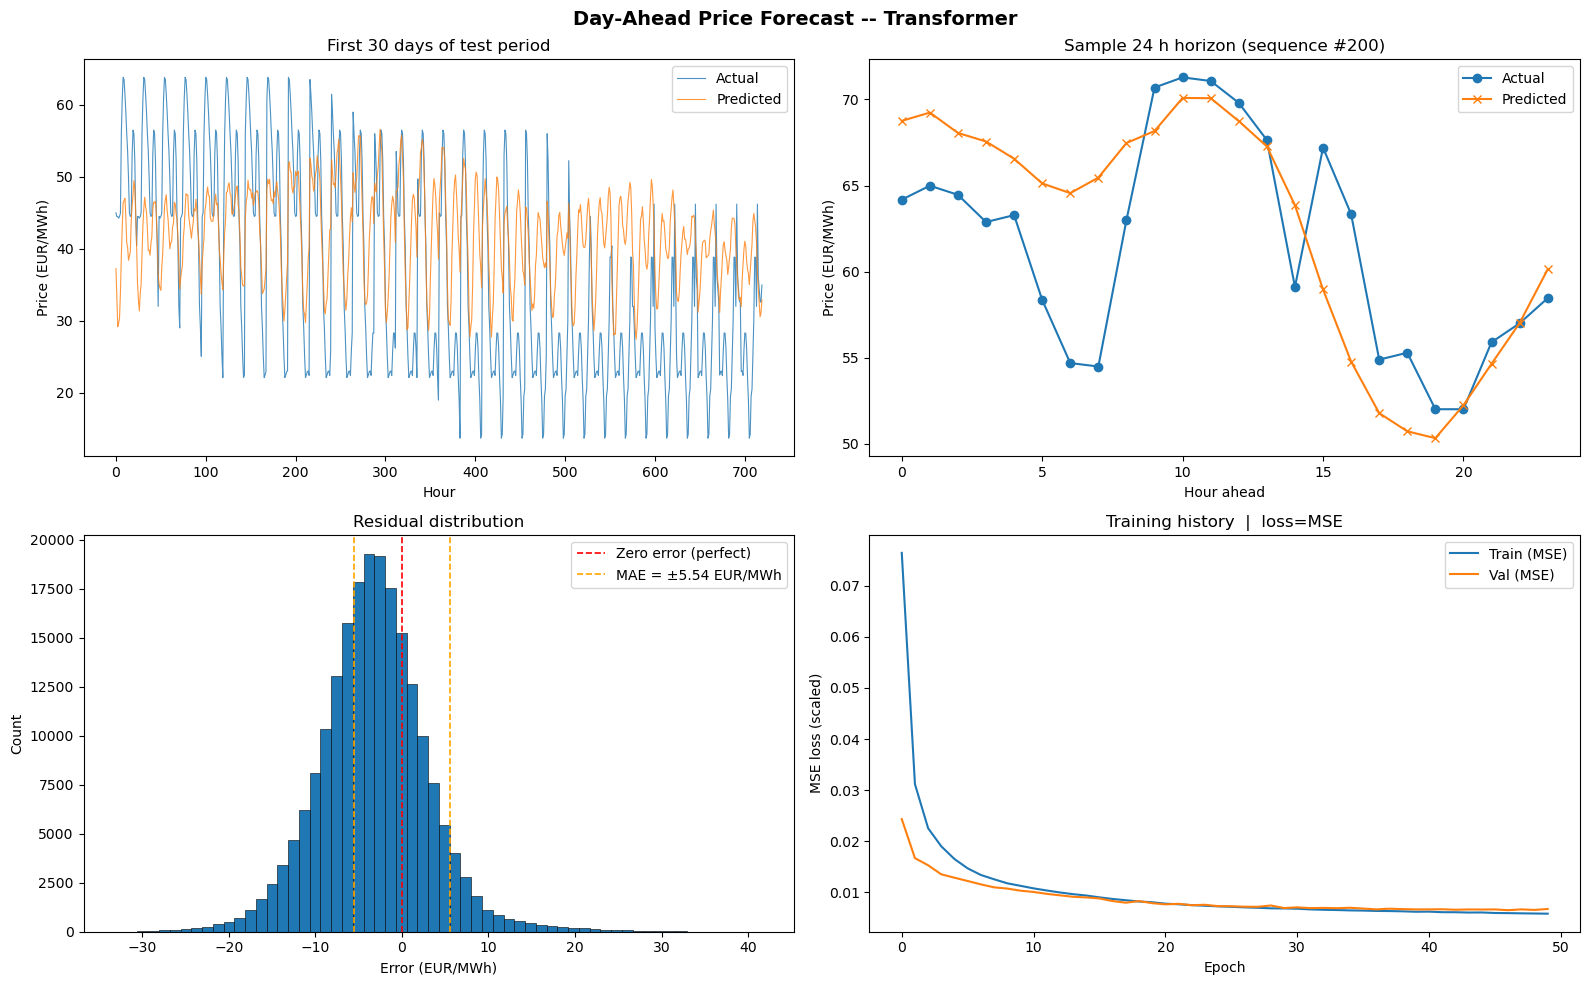

In [31]:
plot_results(results, history, plot_days=30)